<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_13_(DFT%2C_DCT%2C_Wavelet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab - 13**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt

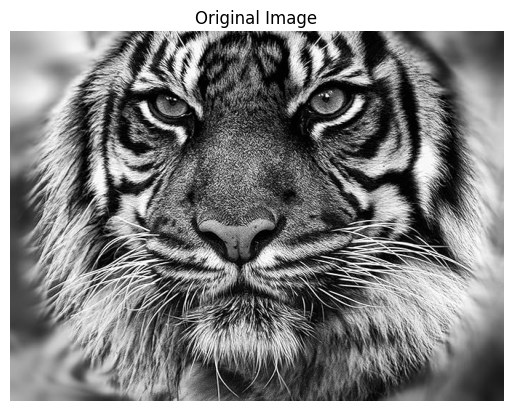

In [3]:
img = cv2.imread('image.jpg', 0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

2D DFT + Magnitude, Log, Phase

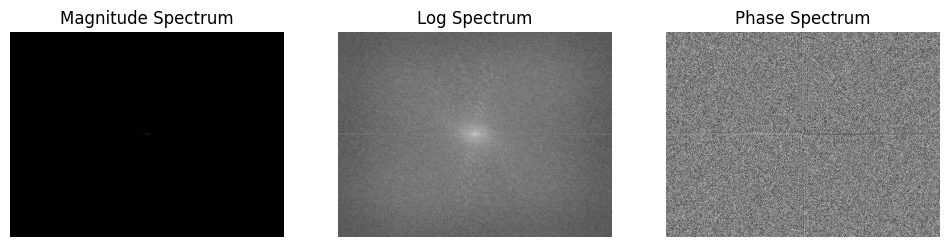

In [4]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

magnitude = np.abs(fshift)
log_spectrum = np.log(1 + magnitude)
phase = np.angle(fshift)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(log_spectrum, cmap='gray')
plt.title("Log Spectrum")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(phase, cmap='gray')
plt.title("Phase Spectrum")
plt.axis('off')

plt.show()

Inverse DFT

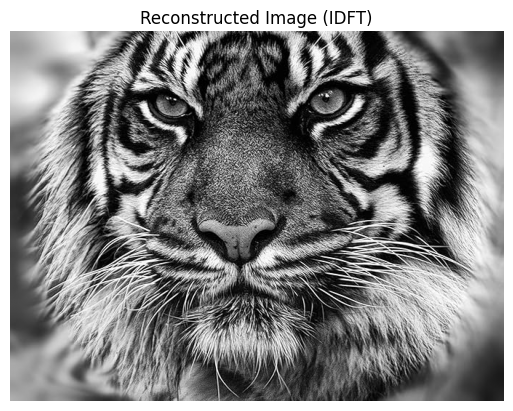

In [5]:
f_ishift = np.fft.ifftshift(fshift)
img_idft = np.fft.ifft2(f_ishift)
img_idft = np.abs(img_idft)

plt.imshow(img_idft, cmap='gray')
plt.title("Reconstructed Image (IDFT)")
plt.axis('off')
plt.show()

2D DCT + IDCT

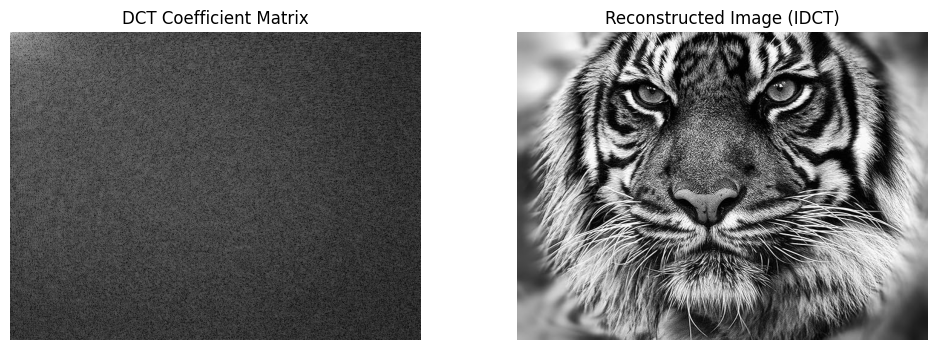

In [6]:
img_float = np.float32(img)

dct = cv2.dct(img_float)
idct = cv2.idct(dct)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(np.log(1 + np.abs(dct)), cmap='gray')
plt.title("DCT Coefficient Matrix")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(idct, cmap='gray')
plt.title("Reconstructed Image (IDCT)")
plt.axis('off')

plt.show()

Haar Wavelet Decomposition

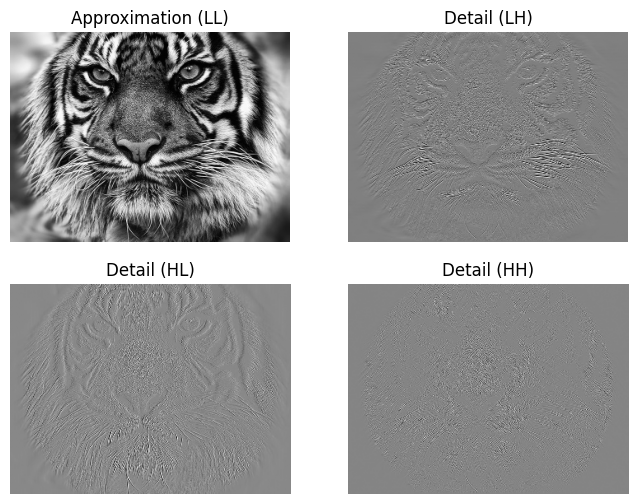

In [7]:
coeffs = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs

plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
plt.imshow(LL, cmap='gray')
plt.title("Approximation (LL)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(LH, cmap='gray')
plt.title("Detail (LH)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(HL, cmap='gray')
plt.title("Detail (HL)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(HH, cmap='gray')
plt.title("Detail (HH)")
plt.axis('off')

plt.show()

Wavelet Edge Detection + Sobel + Canny

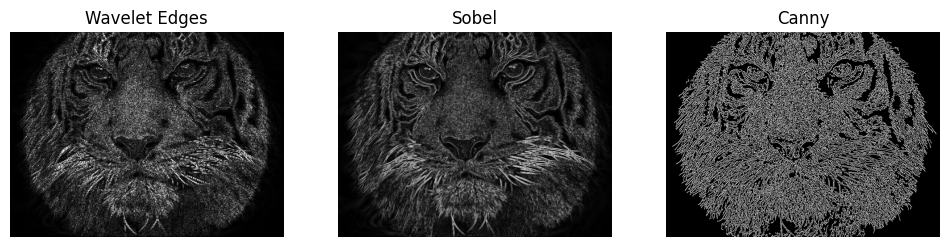

In [8]:
wavelet_edges = np.abs(LH) + np.abs(HL) + np.abs(HH)

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobelx**2 + sobely**2)

canny = cv2.Canny(img, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(wavelet_edges, cmap='gray')
plt.title("Wavelet Edges")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis('off')

plt.show()

Medical Image Comparison

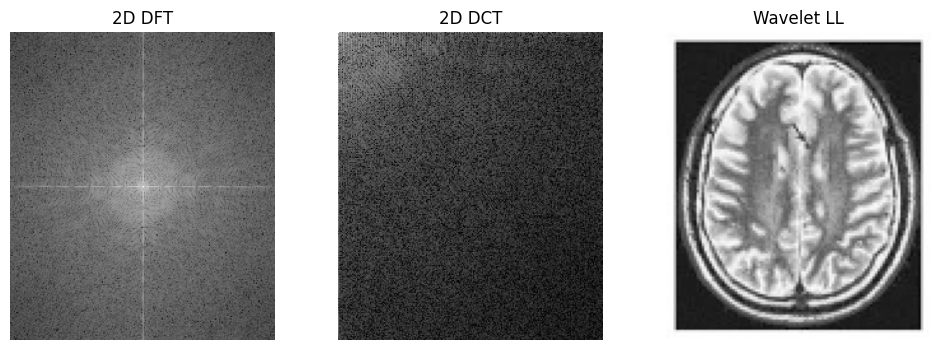

Best for noise removal and diagnostic clarity: Wavelet transform


In [10]:
med = cv2.imread('medical.jpg', 0)

# DFT
f = np.fft.fft2(med)
dft_mag = np.log(1 + np.abs(np.fft.fftshift(f)))

# DCT
dct = cv2.dct(np.float32(med))

# Wavelet
LL, (LH, HL, HH) = pywt.dwt2(med, 'haar')

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(dft_mag, cmap='gray')
plt.title("2D DFT")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(np.log(1 + np.abs(dct)), cmap='gray')
plt.title("2D DCT")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(LL, cmap='gray')
plt.title("Wavelet LL")
plt.axis('off')

plt.show()

print("Best for noise removal and diagnostic clarity: Wavelet transform")